In [21]:
import sys
import os

# Add current directory to path (handle Jupyter where __file__ is not defined)
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # __file__ is not defined in interactive environments like Jupyter notebooks
    current_dir = os.getcwd()
sys.path.insert(0, current_dir)

from celaba_dataset import CelebADataset

# Set up paths to CelebA data
data_root = os.path.join(current_dir, 'CelebA')

# Initialize the dataset
dataset = CelebADataset(
    img_dir=os.path.join(data_root, 'img_align_celeba'),
    attr_path=os.path.join(data_root, 'Anno', 'list_attr_celeba.txt'),
    bbox_path=os.path.join(data_root, 'Anno', 'list_bbox_celeba.txt'),
    landmark_path=os.path.join(data_root, 'Anno', 'list_landmarks_align_celeba.txt'),
    partition_path=os.path.join(data_root, 'Eval', 'list_eval_partition.txt'),
    split='train',
    transform=None  # Add your transforms here
)

# Get a sample
sample = dataset[100]
image = sample['image']
attributes = sample['attributes']
bbox = sample['bbox']
landmarks = sample['landmarks']

print(f"Dataset size: {len(dataset)}")
print(f"Image shape: {image.size}")
print(f"Attributes shape: {attributes.shape}")
print(f"BBox shape: {bbox.shape}")
print(f"Landmarks shape: {landmarks.shape}")

Dataset size: 62771
Image shape: (178, 218)
Attributes shape: torch.Size([40])
BBox shape: torch.Size([4])
Landmarks shape: torch.Size([10])


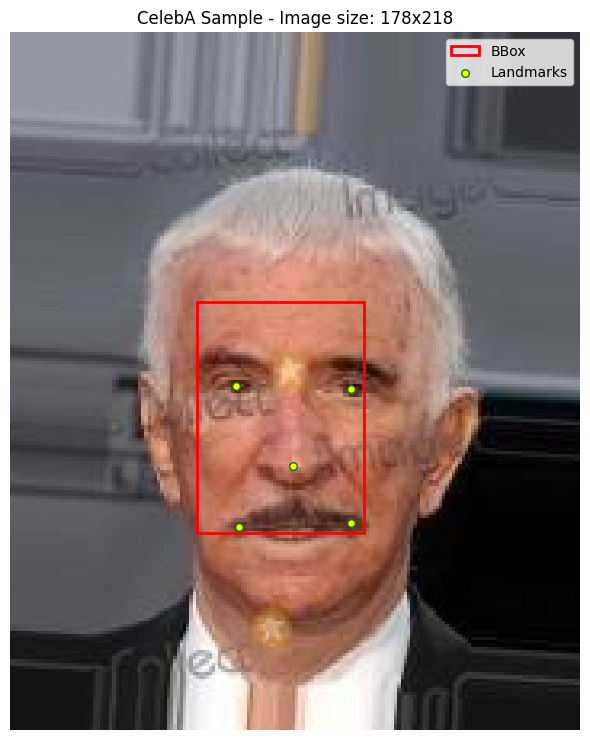

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_sample(sample):
    # Get PIL image and convert to numpy
    img_pil = sample['image']
    img = np.asarray(img_pil).astype(np.float32) / 255.0  # H x W x C
    img_h, img_w = img.shape[0], img.shape[1]
    
    # Convert bbox and landmarks to numpy arrays (handle torch tensors)
    bbox = sample['bbox'].cpu().numpy() if isinstance(sample['bbox'], torch.Tensor) else np.array(sample['bbox'])
    lm = sample['landmarks'].cpu().numpy() if isinstance(sample['landmarks'], torch.Tensor) else np.array(sample['landmarks'])
    
    # The bbox and landmarks were scaled based on the TARGET_SIZE (128, 128)
    # But the displayed image is at original size (img_h, img_w)
    # We need to scale them back: multiply by (orig_w/128, orig_h/128)
    scale_x = img_w / 128.0
    scale_y = img_h / 128.0
    
    # Scale bbox back to original image size
    bbox_scaled = bbox.copy()
    bbox_scaled[0] *= scale_x  # x coordinate
    bbox_scaled[1] *= scale_y  # y coordinate
    bbox_scaled[2] *= scale_x  # width
    bbox_scaled[3] *= scale_y  # height
    
    # Clamp bbox to image bounds
    bbox_scaled[0] = max(0, min(bbox_scaled[0], img_w - 1))
    bbox_scaled[1] = max(0, min(bbox_scaled[1], img_h - 1))
    bbox_scaled[2] = max(0, min(bbox_scaled[2], img_w - bbox_scaled[0]))
    bbox_scaled[3] = max(0, min(bbox_scaled[3], img_h - bbox_scaled[1]))
    
    # Scale landmarks back to original image size
    lm_scaled = lm.copy()
    lm_scaled[0::2] *= scale_x  # x coordinates
    lm_scaled[1::2] *= scale_y  # y coordinates
    
    fig, ax = plt.subplots(figsize=(6, 8))
    ax.imshow(img)
    
    # draw bbox
    x, y, w, h = bbox_scaled
    rect = plt.Rectangle((x, y), w, h, fill=False, color='red', linewidth=2, label='BBox')
    ax.add_patch(rect)
    
    # draw landmarks
    ax.scatter(lm_scaled[0::2], lm_scaled[1::2], s=30, c='yellow', edgecolors='green', linewidth=1, label='Landmarks')
    
    ax.set_title(f'CelebA Sample - Image size: {img_w}x{img_h}')
    ax.legend()
    ax.axis('off')
    plt.tight_layout()
    plt.show()

show_sample(sample)

In [23]:
# Debug: Check raw bbox values
print("Raw bbox values:", bbox.cpu().numpy() if hasattr(bbox, 'cpu') else np.array(bbox))
print("Raw landmarks values:", landmarks.cpu().numpy() if hasattr(landmarks, 'cpu') else np.array(landmarks))
print("\nImage size (original):", image.size)
print("Image shape when displayed:", np.asarray(image).shape)

# Load raw bbox from file to compare
raw_bbox_df = pd.read_csv(os.path.join(data_root, 'Anno', 'list_bbox_celeba.txt'), sep=r"\s+", skiprows=1)
print("\nRaw BBox from file (first few rows):")
print(raw_bbox_df.head())

Raw bbox values: [41.707867 49.3211   37.393257 42.275227]
Raw landmarks values: [50.33708 64.58715 76.22472 65.17431 63.2809  79.26605 51.05618 90.42201
 76.22472 89.83486]

Image size (original): (178, 218)
Image shape when displayed: (218, 178, 3)


NameError: name 'pd' is not defined